# Data Load And Analysis

In [1]:
# Everytime reload the notebook, reload the modules
%load_ext autoreload
%autoreload 2

# Data load and split

import pandas as pd
import os

split_csv = pd.read_csv("data/CelebA1/Eval/list_eval_partition.csv", sep=" ")

train_csv = split_csv[split_csv["split_id"] == 0]
test_csv = split_csv[split_csv["split_id"] == 1]
val_csv = split_csv[split_csv["split_id"] == 2]

print(train_csv.head(10))

image_dir = "data/CelebA1/Img/img_align_celeba"

train_img_paths = train_csv["file_name"].apply(lambda x: os.path.join(image_dir, x))
test_img_paths = test_csv["file_name"].apply(lambda x: os.path.join(image_dir, x))
val_img_paths = val_csv["file_name"].apply(lambda x: os.path.join(image_dir, x))

# convert to list
train_img_paths = train_img_paths.tolist()
test_img_paths = test_img_paths.tolist()
val_img_paths = val_img_paths.tolist()

print(len(train_img_paths))
print(len(test_img_paths))
print(len(val_img_paths))

# compute porportion of each class
prop = split_csv["split_id"].value_counts(normalize=True)

print(prop)

result_dir = None


    file_name  split_id
0  000001.jpg         0
1  000002.jpg         0
2  000003.jpg         0
3  000004.jpg         0
4  000005.jpg         0
5  000006.jpg         0
6  000007.jpg         0
7  000008.jpg         0
8  000009.jpg         0
9  000010.jpg         0
162770
19867
19962
split_id
0    0.803410
2    0.098530
1    0.098061
Name: proportion, dtype: float64


In [36]:
# Load datasets
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from my_dataset import CustomImageDataset

BATCH_SIZE = 400
IMG_SIZE = (64, 64)

transform = transforms.Compose([
    transforms.CenterCrop((178, 178)),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    # normalize to [-1, 1] for tanh activation
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


train_dataset = CustomImageDataset(train_img_paths, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = CustomImageDataset(val_img_paths, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = CustomImageDataset(test_img_paths, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(len(train_dataset), len(train_loader), len(train_loader)*BATCH_SIZE)

162770 407 162800


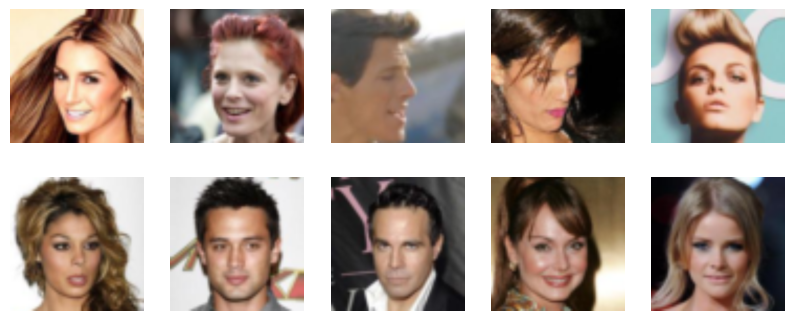

In [37]:
# Show example of images
import matplotlib.pyplot as plt

inv_transform = transforms.Compose([
    # denormalize
    transforms.Lambda(lambda x: (x * 0.5) + 0.5),
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
])

# show image in 2*5 grid
plt.figure(figsize=(10, 4))

for i, image in enumerate(train_dataset):
    if i == 10:
        break
    img = inv_transform(image)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.show()



In [38]:
# Build Beta-VAE
from models.beta_vae import BetaVAE
from models.beta_tc_vae import BetaTCVAE
import torch

# Training epochs
epochs = 60

LOSS_TYPE = 'Cyclical'  # 'H', 'B', 'PID', 'Cyclical'
# PID controller parameters --- IGNORE ---
EXP_KLD_LOSS = 10
# H parameters --- IGNORE ---
BETA = 2
# B parameters --- IGNORE ---
GAMMA = 20
MAX_CAPACITY = 400
# Cyclical parameters
TOTAL_STEPS = epochs * len(train_loader)
MAX_BETA = 4
RATIO = 0.5
MODE = 'linear'  # 'linear' or 'sigmoid'

# loss weights
ENABLE_PERCEPTUAL_LOSS = False
LPIPS_WEIGHT = 1.2

TVL_WEIGHT = 1e-3

# Define hidden dimensions
HIDDEN_DIMS = [32, 64, 128, 256, 512]

# MODEL_NAME = "beta_tc_vae"
MODEL_NAME = "beta_vae"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LATENT_DIM = 128

if MODEL_NAME == "beta_tc_vae":
    # Arg set for Beta-TC-VAE
    ANNEAL_STEPS = 200
    ALPHA = 1
    BETA = 1
    GAMMA = 1

    model = BetaTCVAE(in_channels=3, latent_dim=LATENT_DIM,
                      hidden_dims=HIDDEN_DIMS, anneal_steps=ANNEAL_STEPS, alpha=ALPHA, beta=BETA, gamma=GAMMA,
                      enable_perceptual_loss=ENABLE_PERCEPTUAL_LOSS,
                      lpips_weight=LPIPS_WEIGHT, tvl_weight=TVL_WEIGHT)
else:
    model = BetaVAE(in_channels=3, loss_type=LOSS_TYPE, gamma=GAMMA, latent_dim=LATENT_DIM,
                    hidden_dims=HIDDEN_DIMS, image_size=IMG_SIZE,
                    beta=BETA, max_capacity=MAX_CAPACITY, exp_kld_loss=EXP_KLD_LOSS, enable_perceptual_loss=ENABLE_PERCEPTUAL_LOSS,
                    lpips_weight=LPIPS_WEIGHT, tvl_weight=TVL_WEIGHT,
                    total_steps=TOTAL_STEPS, max_beta=MAX_BETA, ratio=RATIO, circular_mode=MODE)
model.to(device)

BetaVAE(
  (encoder): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), padding_mode=reflect)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), padding_mode=reflect)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), padding_mode=reflect)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (3): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), padding_mode=reflect)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, 

In [39]:
# Training a VAE on CelebA
import logging
import os
import torch
from models.base import BaseVAE
from torchvision.utils import save_image
from tqdm import tqdm
from typing import Dict
# import defaultdict
from collections import defaultdict


def train(model: BaseVAE, train_loader, optimizer, epoch, device):
    model.train()

    epoch_loss_dict = defaultdict(float)

    loop = tqdm(train_loader, desc=f'Train Epoch {epoch}')

    for batch_idx, data in enumerate(loop):
        data = data.to(device)

        optimizer.zero_grad()

        res = model.forward(data)

        loss_dict = model.loss_function(
            *res, M_N=data.size(0)/len(train_loader.dataset), is_val=False)

        loss = loss_dict['loss']
        loss.backward()
        optimizer.step()

        for k, v in loss_dict.items():
            epoch_loss_dict[k] += v.item()

    for k in epoch_loss_dict.keys():
        epoch_loss_dict[k] /= len(train_loader)

    return epoch_loss_dict


def validate(model: BaseVAE, val_loader, epoch, device, result_dir: str, train_data_len: float):
    model.eval()  # 切换到评估模式 (关闭 Dropout/BatchNum 统计更新)

    epoch_loss_dict = defaultdict(float)

    loop = tqdm(val_loader, desc=f'Validation Epoch {epoch}')
    with torch.no_grad():  # 验证阶段不需要计算梯度，节省显存
        for batch_idx, data in enumerate(loop):
            data = data.to(device)

            # 1. 前向传播
            res = model.forward(data)

            # 2. 计算 Loss (必须和训练时的 Loss 函数一致)
            # 这里的 M_N 相当于 beta-VAE 里的 beta
            kld_weight = data.size(0)/train_data_len
            loss_dict = model.loss_function(*res, M_N=kld_weight, is_val=True)

            for k, v in loss_dict.items():
                epoch_loss_dict[k] += v.item()

            # 3. 可视化 (只在第一个 Batch 做，避免存太多图)
            if batch_idx == 0:
                # 比较：原图 vs 重构图
                # n=8 表示显示前8张。cat 把原图和重构图上下拼起来
                recons = res[0]
                comparison = torch.cat([data[:8], recons[:8]])
                save_image(comparison.cpu(
                ), f'{result_dir}/reconstruction_{epoch}.png', nrow=8, normalize=True)

    for k in epoch_loss_dict.keys():
        epoch_loss_dict[k] /= len(val_loader)

    # Random sampling
    with torch.no_grad():
        z = torch.randn(8, model.latent_dim).to(device)
        sample = model.decode(z)
        save_image(
            sample.cpu(), f'{result_dir}/sample_{epoch}.png', nrow=8, normalize=True)

    return epoch_loss_dict

In [40]:
# Training model
import os
import json
from torch import optim
import logging
# Scheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch


optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5)

train_losses = []

val_losses = []


best_recon_loss = float('inf')
no_improvement = 0
early_stopping_patience = 10
early_epoch = 10

# create results directory
result_dir = f"results_{MODEL_NAME}_ImSize{IMG_SIZE[0]}_Lat{LATENT_DIM}"
if ENABLE_PERCEPTUAL_LOSS:
    result_dir += f"_TVL{int(TVL_WEIGHT*1e4)}_LPIPS{int(LPIPS_WEIGHT*10)}"

if MODEL_NAME == "beta_tc_vae":
    result_dir += f"_Alpha{ALPHA}_Beta{BETA}_Gamma{GAMMA}"
else:
    result_dir += f"_{LOSS_TYPE}"
    if LOSS_TYPE == 'H':
        result_dir += f"_Beta{BETA}"
    elif LOSS_TYPE == 'B':
        result_dir += f"_G{GAMMA}_C{MAX_CAPACITY}"
    elif LOSS_TYPE == 'PID':
        result_dir += f"_EXP{EXP_KLD_LOSS}"
    elif LOSS_TYPE == 'Cyclical':
        result_dir += f"_MaxBeta{MAX_BETA}_Ratio{int(RATIO*100)}_{MODE}"
os.makedirs(result_dir, exist_ok=True)

# write all hyperparameters to a json file
# using lowercase keys
with open(f"{result_dir}/hyperparameters.json", "w") as f:
    hyperparams = {
        "model_name": MODEL_NAME,
        "image_size": IMG_SIZE[0],
        "latent_dim": LATENT_DIM,
        "loss_type": LOSS_TYPE,
        "beta": BETA,
        "gamma": GAMMA,
        "max_capacity": MAX_CAPACITY,
        "exp_kld_loss": EXP_KLD_LOSS,
        "total_steps": TOTAL_STEPS,
        "max_beta": MAX_BETA,
        "ratio": RATIO,
        "circular_mode": MODE,
        "enable_perceptual_loss": ENABLE_PERCEPTUAL_LOSS,
        "lpips_weight": LPIPS_WEIGHT,
        "tvl_weight": TVL_WEIGHT,
        "epochs": epochs,
        "batch_size": BATCH_SIZE,
        "hidden_dims": HIDDEN_DIMS,
        "alpha": ALPHA,
        "anneal_steps": ANNEAL_STEPS,
        # Add more hyperparameters as needed
    }
    json.dump(hyperparams, f, indent=4)

start_epoch = 0

# Load existing model if any
model_path = f"{result_dir}/last_{MODEL_NAME}.pth"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    # get the epoch from samples images names
    sample_files = [f for f in os.listdir(
        result_dir) if f.startswith("sample_") and f.endswith(".png")]
    if sample_files:
        sample_epochs = [int(f.split("_")[1].split(".")[0])
                         for f in sample_files]
        start_epoch = max(sample_epochs) + 1
    logging.info(f"Loaded existing model from {model_path}")

logging.basicConfig(level=logging.INFO)
logging.info("Training started")


for epoch in range(start_epoch, epochs):
    train_loss_dict = train(model, train_loader, optimizer, epoch, device)
    train_losses.append(train_loss_dict)

    logging.info(f"Epoch {epoch}, Train BCE Loss: {train_loss_dict["Reconstruction_Loss"]:.4f}, \
                 Train KLD Loss: {train_loss_dict["KLD_Loss"]:.4f}, Train Loss: {train_loss_dict["loss"]:.4f}")

    val_loss_dict = validate(model, val_loader, epoch,
                             device, result_dir, len(train_dataset))
    val_losses.append(val_loss_dict)

    logging.info(f"Epoch {epoch}, Val BCE Loss: {val_loss_dict["Reconstruction_Loss"]:.4f},\
                  Val KLD Loss: {val_loss_dict["KLD_Loss"]:.4f}, Val Loss: {val_loss_dict["loss"]:.4f}")

    if epoch < early_epoch:
        continue
    recon_loss = val_loss_dict["Reconstruction_Loss"]
    if recon_loss < best_recon_loss:
        best_recon_loss = recon_loss
        no_improvement = 0
        # save model
        torch.save(model.state_dict(), f"{result_dir}/best_{MODEL_NAME}.pth")
    else:
        no_improvement += 1
        if no_improvement >= early_stopping_patience:
            logging.info(f"Early stopping at epoch {epoch}")
            break

# save model
torch.save(model.state_dict(), f"{result_dir}/last_{MODEL_NAME}.pth")

logging.info(f"Training Finished")

INFO:root:Training started
Train Epoch 0: 100%|██████████| 407/407 [01:42<00:00,  3.96it/s]
INFO:root:Epoch 0, Train BCE Loss: 0.1220,                  Train KLD Loss: 19315.9335, Train Loss: 0.2555
Validation Epoch 0: 100%|██████████| 50/50 [00:10<00:00,  4.85it/s]
INFO:root:Epoch 0, Val BCE Loss: 0.0813,                  Val KLD Loss: 30.7134, Val Loss: 0.1064
Train Epoch 1: 100%|██████████| 407/407 [01:43<00:00,  3.94it/s]
INFO:root:Epoch 1, Train BCE Loss: 0.0805,                  Train KLD Loss: 23.8333, Train Loss: 0.1091
Validation Epoch 1: 100%|██████████| 50/50 [00:10<00:00,  4.82it/s]
INFO:root:Epoch 1, Val BCE Loss: 0.0817,                  Val KLD Loss: 19.5911, Val Loss: 0.1138
Train Epoch 2: 100%|██████████| 407/407 [01:41<00:00,  4.00it/s]
INFO:root:Epoch 2, Train BCE Loss: 0.0841,                  Train KLD Loss: 17.2766, Train Loss: 0.1192
Validation Epoch 2: 100%|██████████| 50/50 [00:10<00:00,  4.71it/s]
INFO:root:Epoch 2, Val BCE Loss: 0.0877,                  Val K

In [46]:
# save training and validation losses
import pandas as pd
# save training and validation losses
train_loss_df = pd.DataFrame(train_losses[1:])
val_loss_df = pd.DataFrame(val_losses[1:])
train_loss_df.to_csv(f"{result_dir}/train_losses.csv", index=False)
val_loss_df.to_csv(f"{result_dir}/val_losses.csv", index=False)

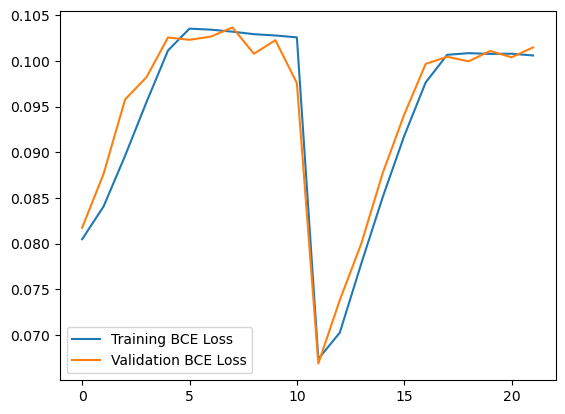

In [52]:
# Visulization Losses
import matplotlib.pyplot as plt
# draw train and val Reconstruction Loss
plt.plot([loss_dict["Reconstruction_Loss"]
         for loss_dict in train_losses[1:]], label='Training BCE Loss')
plt.plot([loss_dict["Reconstruction_Loss"]
         for loss_dict in val_losses[1:]], label='Validation BCE Loss')

plt.legend()
plt.savefig(f"{result_dir}/recon_loss_curve.png")
plt.show()

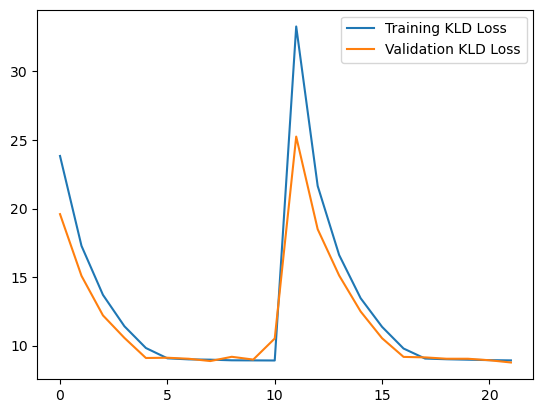

In [53]:
# draw train and val KLD Loss
plt.plot([loss_dict["KLD_Loss"]
         for loss_dict in train_losses[1:]], label='Training KLD Loss')
plt.plot([loss_dict["KLD_Loss"]
         for loss_dict in val_losses[1:]], label='Validation KLD Loss')
plt.legend()
# save figure
plt.savefig(f"{result_dir}/kld_loss_curve.png")
plt.show()

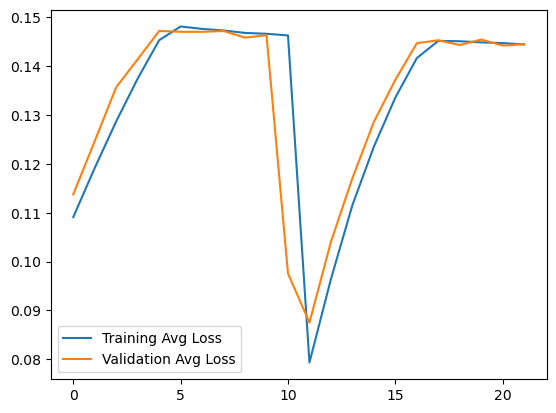

In [54]:
# draw train and val loss
plt.plot([loss_dict["loss"]
         for loss_dict in train_losses[1:]], label='Training Avg Loss')
plt.plot([loss_dict["loss"]
         for loss_dict in val_losses[1:]], label='Validation Avg Loss')

plt.legend()
# save figure
plt.savefig(f"{result_dir}/loss_curve.png")
plt.show()

In [45]:
# if exists TC_Loss and MI_Loss, draw them

if MODEL_NAME == "beta_tc_vae":
    # draw TC Loss
    plt.plot([loss_dict["TC_Loss"]
             for loss_dict in train_losses], label='Training TC Loss')
    plt.plot([loss_dict["TC_Loss"]
             for loss_dict in val_losses], label='Validation TC Loss')
    plt.legend()
    plt.savefig(f"{result_dir}/tc_loss_curve.png")
    plt.show()

    # draw MI Loss
    plt.plot([loss_dict["MI_Loss"]
             for loss_dict in train_losses], label='Training MI Loss')
    plt.plot([loss_dict["MI_Loss"]
             for loss_dict in val_losses], label='Validation MI Loss')
    plt.legend()
    plt.savefig(f"{result_dir}/mi_loss_curve.png")
    plt.show()